# 1.빈도수 분석
- 빈도수 분석은 텍스트 데이터에서 특정 단어나 표현이 얼마나 자주 등장하는지를 세어 단어의 중요도와 패턴을 파악하는 방법이다.
- 이 분석은 텍스트 데이터의 기본적이면서도 매우 중요한 분석 기법이다.
- 단어 또는 표현이 등장한 횟수(Frequency)를 세어 가장 자주 등장하는 단어가 무엇인지 파악한다.
이를 통해 문서의 주제, 관심사, 주요 키워드를 알 수 있다.


In [5]:
import os
# os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-21.0.11"

from konlpy.tag import Okt
from collections import Counter
import pandas as pd

In [6]:
document = pd.read_csv("result.csv", encoding="utf-8-sig")
reviews = document.iloc[:, 3].astype(str).tolist()

In [9]:
# 명사만 추출
okt = Okt()

morphs = okt.nouns(reviews[0])
morphs


['오늘', '포인트', '업데이트', '하라', '문구', '업데이트']

In [10]:
# 빈도수 분석
freq_dict = dict(Counter(morphs))
freq_dict

sorted_dict = sorted(freq_dict.items(),
                     key = lambda item : item[1],       # 튜플의 두 번째 요소(빈도수)를 정렬 기준으로 사용
                     reverse = True                     # 내림차순
                     )
sorted_dict                  


[('업데이트', 2), ('오늘', 1), ('포인트', 1), ('하라', 1), ('문구', 1)]

In [11]:
import pandas as pd

df = pd.DataFrame(sorted_dict)
df.index = df[0]
del df[0]
df

,1
0,
업데이트,2
오늘,1
포인트,1
하라,1
문구,1


# 2.워드클라우드

In [15]:
df = pd.read_csv('result.csv')

df

,작성자,평점,날짜,리뷰내용
0,강성원,1,2026-05-30 23:38:18,오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음
1,고태성,4,2026-05-30 23:02:01,좋아요
2,김기형,5,2026-05-30 22:56:35,편리함
3,최경자,5,2026-05-30 22:49:31,재미있어요
4,정현정카슈,3,2026-05-30 22:44:51,잘모르겠음
...,...,...,...,...
140,jiheon Song,5,2026-05-30 00:15:00,앱은 편리하고 좋은데 관리하시는분들이 너무 편하게 일하려는듯한 느낌을받았어요...이...
141,이동훈,5,2026-05-30 00:13:50,👍
142,문재순,1,2026-05-30 00:12:14,했는데도 계속 업데이트 하라고 뜨네요ㅠ
143,조은새,5,2026-05-30 00:10:41,앱은 작동하고 서비스가있지만다음내용화면이 알수없는것


In [16]:
# 인덱스와 댓글만 나오도록
df = df.dropna()
df = df.reset_index()
df.drop(['작성자','평점','날짜'], axis=1, inplace=True)
df.head()

,index,리뷰내용
0,0,오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음
1,1,좋아요
2,2,편리함
3,3,재미있어요
4,4,잘모르겠음


In [17]:
df = df.drop_duplicates(subset=['리뷰내용'])        # '댓글' 열을 기준으로 중복된 행을 제거
df

,index,리뷰내용
0,0,오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음
1,1,좋아요
2,2,편리함
3,3,재미있어요
4,4,잘모르겠음
...,...,...
140,140,앱은 편리하고 좋은데 관리하시는분들이 너무 편하게 일하려는듯한 느낌을받았어요...이...
141,141,👍
142,142,했는데도 계속 업데이트 하라고 뜨네요ㅠ
143,143,앱은 작동하고 서비스가있지만다음내용화면이 알수없는것


In [18]:
text_data = ''

for temp in df['리뷰내용']:
    text_data = text_data + ' ' + temp

text_data

" 오늘의 포인트를 하려면 업데이트를.하라고 문구가 뜨는데 업데이트가 되지 않음 좋아요 편리함 재미있어요 잘모르겠음 수수료없고 매일 이자주고 다 좋은데 방송봤는데 포인트 안들어오구ㅡㅡ업뎃하래서 했는데 계속 업뎃해야 이용가능하다 뜨고 결국 업뎃만 벌써 5~6번하는거 같은데 언제 반영되나요??? 매우좋음 통장 잔액을 보려고 할때 재부팅이 느린건지 잔액이 얼마 남았는지 확인하는데 많은 시간이 걸림 재미삼아 날마다 앱 열고 하고있습니다 포인트를 5원 1원 주지 말고 50원이라도 주시오ㅠㅠ 좋습니다 공유합니다 사용하기 편리해서 좋아요 ~ ☆☆☆☆☆ 아주좋아요 앱 실행하면 상단에 대출광고 너무 많이 뜹니다. x표시 눌러도 계속 뜹니다. 길거리에서 명함 뿌리는 사채업자랑 뭐가 다릅니까? 일주일 방문 미션할때 가끔은 정답을 맞혀도 정답이 인정 안되고 그럴때도 있는데 즐겁게 토스앱 이용 하고 있습니다 이번주미션이안열려요 토스가작동하지않내요빨리고쳐주세요 편리해요 업데이트하라고 무한반복 열기를 눌렀는데도 계속 제자리. 서버를 안정화 시키고 실행시키시지요! 환급해준다면서 준비서류 안내도없이 순서대로 결제하니까 마지막에 서류요구하네 이새키들이? 서류있었으면 종소세 경정청구했겠지. 장난까냐? 부동산없어져서 서류구하지도못하는데 염장지르네 돈많이벌어먹으세요. 엔화로 장난치더니 이제 환급으로 장난질이네 만보기 복권 다 100만원 10만원 기본이 10000원인데 저 3원 6원 8원 많이주면 10윈입니다 매일 10000키로 걸으면뭐합니까 너무합니다 사람 차별하나요 아님 저 무시하는겁니까 유용하게 사용중입니다 토스 측에선 돈독 올랐는지 어떻게든 환급금 수수료 때먹구 싶어서 알림 설정 전부 해제해도 거슬리게 배너 띄우고 욕나오게 만듭니다 공유해요. 미션 클릭하면 업데이트 하라고만 뜨고 업데이트가 안됨 조아요 5월 29일에 이번 주 미션이 '오늘의 포인트 미션'으로 바뀌었는데 언제부터 이용 가능하게 해주실건가요? 업데이트하라고는 하는데 이틀째 업데이트 하라고 플레이스토어 앱에서 나오지도 않네요? 포

In [29]:
# %pip install wordcloud
# uv add wordcloud

In [19]:
# 워드클라우드 라이브러리 불러오기
from wordcloud import WordCloud
import re


In [20]:
# 한글, 공백을 제외한 모든 문자 제거

kor_data = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣\s]', '', text_data)
kor_data

' 오늘의 포인트를 하려면 업데이트를하라고 문구가 뜨는데 업데이트가 되지 않음 좋아요 편리함 재미있어요 잘모르겠음 수수료없고 매일 이자주고 다 좋은데 방송봤는데 포인트 안들어오구ㅡㅡ업뎃하래서 했는데 계속 업뎃해야 이용가능하다 뜨고 결국 업뎃만 벌써 번하는거 같은데 언제 반영되나요 매우좋음 통장 잔액을 보려고 할때 재부팅이 느린건지 잔액이 얼마 남았는지 확인하는데 많은 시간이 걸림 재미삼아 날마다 앱 열고 하고있습니다 포인트를 원 원 주지 말고 원이라도 주시오ㅠㅠ 좋습니다 공유합니다 사용하기 편리해서 좋아요   아주좋아요 앱 실행하면 상단에 대출광고 너무 많이 뜹니다 표시 눌러도 계속 뜹니다 길거리에서 명함 뿌리는 사채업자랑 뭐가 다릅니까 일주일 방문 미션할때 가끔은 정답을 맞혀도 정답이 인정 안되고 그럴때도 있는데 즐겁게 토스앱 이용 하고 있습니다 이번주미션이안열려요 토스가작동하지않내요빨리고쳐주세요 편리해요 업데이트하라고 무한반복 열기를 눌렀는데도 계속 제자리 서버를 안정화 시키고 실행시키시지요 환급해준다면서 준비서류 안내도없이 순서대로 결제하니까 마지막에 서류요구하네 이새키들이 서류있었으면 종소세 경정청구했겠지 장난까냐 부동산없어져서 서류구하지도못하는데 염장지르네 돈많이벌어먹으세요 엔화로 장난치더니 이제 환급으로 장난질이네 만보기 복권 다 만원 만원 기본이 원인데 저 원 원 원 많이주면 윈입니다 매일 키로 걸으면뭐합니까 너무합니다 사람 차별하나요 아님 저 무시하는겁니까 유용하게 사용중입니다 토스 측에선 돈독 올랐는지 어떻게든 환급금 수수료 때먹구 싶어서 알림 설정 전부 해제해도 거슬리게 배너 띄우고 욕나오게 만듭니다 공유해요 미션 클릭하면 업데이트 하라고만 뜨고 업데이트가 안됨 조아요 월 일에 이번 주 미션이 오늘의 포인트 미션으로 바뀌었는데 언제부터 이용 가능하게 해주실건가요 업데이트하라고는 하는데 이틀째 업데이트 하라고 플레이스토어 앱에서 나오지도 않네요 포인트 얻지 말라는건가요 그럴거면 차라리 이전 것으로 되돌려 놓으세요 수수료 먼저 받아가는게 말이 되

In [21]:
# 한글 정제된 데이터에 대해 품사 태깅

okt = Okt()
okt_data = okt.pos(kor_data)
okt_data

# 반환 결과 : 리스트형식 (단어, 품사 태그) 형태의 튜플로 구성

[('오늘', 'Noun'),
 ('의', 'Josa'),
 ('포인트', 'Noun'),
 ('를', 'Josa'),
 ('하려면', 'Verb'),
 ('업데이트', 'Noun'),
 ('를', 'Josa'),
 ('하라', 'Noun'),
 ('고', 'Josa'),
 ('문구', 'Noun'),
 ('가', 'Josa'),
 ('뜨는데', 'Verb'),
 ('업데이트', 'Noun'),
 ('가', 'Josa'),
 ('되지', 'Verb'),
 ('않음', 'Verb'),
 ('좋아요', 'Adjective'),
 ('편리함', 'Adjective'),
 ('재미있어요', 'Adjective'),
 ('잘', 'VerbPrefix'),
 ('모르겠음', 'Verb'),
 ('수수료', 'Noun'),
 ('없고', 'Adjective'),
 ('매일', 'Noun'),
 ('이', 'Determiner'),
 ('자주', 'Noun'),
 ('고', 'Josa'),
 ('다', 'Adverb'),
 ('좋은데', 'Adjective'),
 ('방송', 'Noun'),
 ('봤는데', 'Verb'),
 ('포인트', 'Noun'),
 ('안', 'VerbPrefix'),
 ('들어오구', 'Verb'),
 ('ㅡㅡ', 'KoreanParticle'),
 ('업뎃', 'Noun'),
 ('하래', 'Noun'),
 ('서', 'Josa'),
 ('했는데', 'Verb'),
 ('계속', 'Noun'),
 ('업뎃해', 'Noun'),
 ('야', 'Josa'),
 ('이용', 'Noun'),
 ('가능하다', 'Adjective'),
 ('뜨고', 'Verb'),
 ('결국', 'Adverb'),
 ('업뎃', 'Noun'),
 ('만', 'Josa'),
 ('벌써', 'Noun'),
 ('번하는거', 'Adjective'),
 ('같은데', 'Adjective'),
 ('언제', 'Noun'),
 ('반영', 'Noun'),
 ('되나요', 'Verb

In [22]:
words = []

for word, tag in okt_data:
    if tag in ['Noun', 'Adjective']:
        if len(word) > 1:
            words.append(word)              # 한글자는 제거

words

['오늘',
 '포인트',
 '업데이트',
 '하라',
 '문구',
 '업데이트',
 '좋아요',
 '편리함',
 '재미있어요',
 '수수료',
 '없고',
 '매일',
 '자주',
 '좋은데',
 '방송',
 '포인트',
 '업뎃',
 '하래',
 '계속',
 '업뎃해',
 '이용',
 '가능하다',
 '업뎃',
 '벌써',
 '번하는거',
 '같은데',
 '언제',
 '반영',
 '매우',
 '좋음',
 '통장',
 '잔액',
 '재부팅',
 '느린',
 '잔액',
 '얼마',
 '확인',
 '많은',
 '시간',
 '재미',
 '포인트',
 '주지',
 '시오',
 '좋습니다',
 '공유',
 '사용',
 '편리해서',
 '좋아요',
 '아주',
 '좋아요',
 '실행',
 '상단',
 '대출',
 '광고',
 '표시',
 '계속',
 '길거리',
 '명함',
 '사채',
 '업자',
 '다릅니까',
 '일주일',
 '방문',
 '미션',
 '가끔',
 '정답',
 '정답',
 '인정',
 '안되고',
 '그럴',
 '있는데',
 '즐겁게',
 '토스',
 '이용',
 '있습니다',
 '이번',
 '미션',
 '이안',
 '토스',
 '작동',
 '편리해요',
 '업데이트',
 '무한',
 '반복',
 '열기',
 '계속',
 '제자리',
 '서버',
 '안정화',
 '실행',
 '환급',
 '준비',
 '서류',
 '안내',
 '순서대로',
 '결제',
 '마지막',
 '서류',
 '요구',
 '서류',
 '있었으면',
 '경정',
 '청구',
 '장난',
 '부동산',
 '류구',
 '지도',
 '염장',
 '엔화',
 '장난',
 '이제',
 '환급',
 '장난',
 '보기',
 '복권',
 '만원',
 '만원',
 '기본',
 '윈입니',
 '매일',
 '뭐합',
 '너무합니다',
 '사람',
 '차별',
 '하나요',
 '아님',
 '무시',
 '유용하게',
 '사용',
 '입니다',
 '토스',
 '돈독',
 '환급금',
 '수수료',
 '알림

In [24]:
# 불용어 제거 집합 만들기

stop_words = '당연히 계속'
stop_words = set(stop_words.split())
stop_words

{'계속', '당연히'}

In [25]:
# stop words 제거
word_data = []

# 불용어 제거
for temp in words:
    if not temp in stop_words:
        word_data.append(temp)

# 최종 불용어 제거 후 단어 리스트의 길이 출력
len(word_data)

847

In [26]:
# 단어 빈도수 계산
count_data = Counter(word_data)

# 가장 많이 등장하는 100개의 단어 추출
c_data = count_data.most_common(100)
c_data

[('업데이트', 58),
 ('미션', 29),
 ('토스', 19),
 ('사용', 18),
 ('포인트', 16),
 ('좋아요', 16),
 ('이번', 15),
 ('하라', 13),
 ('오늘', 12),
 ('있습니다', 8),
 ('수수료', 7),
 ('광고', 7),
 ('업뎃', 6),
 ('이용', 6),
 ('무한', 6),
 ('반복', 5),
 ('알림', 5),
 ('은행', 5),
 ('증권', 5),
 ('주식', 5),
 ('버튼', 5),
 ('편리함', 4),
 ('시간', 4),
 ('안되고', 4),
 ('결제', 4),
 ('장난', 4),
 ('보기', 4),
 ('입니다', 4),
 ('방법', 4),
 ('안되네요', 4),
 ('삭제', 4),
 ('계좌', 4),
 ('좋은', 4),
 ('있어요', 4),
 ('같은', 4),
 ('현금', 4),
 ('다시', 4),
 ('좋은데', 3),
 ('언제', 3),
 ('좋음', 3),
 ('잔액', 3),
 ('확인', 3),
 ('재미', 3),
 ('실행', 3),
 ('환급', 3),
 ('서류', 3),
 ('요구', 3),
 ('사람', 3),
 ('설정', 3),
 ('자꾸', 3),
 ('알람', 3),
 ('상품', 3),
 ('추가', 3),
 ('점점', 3),
 ('생각', 3),
 ('오류', 3),
 ('금융', 3),
 ('편리하고', 3),
 ('구매', 3),
 ('점검', 3),
 ('매일', 2),
 ('하래', 2),
 ('같은데', 2),
 ('매우', 2),
 ('통장', 2),
 ('재부팅', 2),
 ('많은', 2),
 ('공유', 2),
 ('아주', 2),
 ('표시', 2),
 ('일주일', 2),
 ('정답', 2),
 ('있는데', 2),
 ('작동', 2),
 ('열기', 2),
 ('안내', 2),
 ('이제', 2),
 ('만원', 2),
 ('해제', 2),
 ('클릭', 2),
 ('안됨', 2),

In [27]:
dict(c_data)

{'업데이트': 58,
 '미션': 29,
 '토스': 19,
 '사용': 18,
 '포인트': 16,
 '좋아요': 16,
 '이번': 15,
 '하라': 13,
 '오늘': 12,
 '있습니다': 8,
 '수수료': 7,
 '광고': 7,
 '업뎃': 6,
 '이용': 6,
 '무한': 6,
 '반복': 5,
 '알림': 5,
 '은행': 5,
 '증권': 5,
 '주식': 5,
 '버튼': 5,
 '편리함': 4,
 '시간': 4,
 '안되고': 4,
 '결제': 4,
 '장난': 4,
 '보기': 4,
 '입니다': 4,
 '방법': 4,
 '안되네요': 4,
 '삭제': 4,
 '계좌': 4,
 '좋은': 4,
 '있어요': 4,
 '같은': 4,
 '현금': 4,
 '다시': 4,
 '좋은데': 3,
 '언제': 3,
 '좋음': 3,
 '잔액': 3,
 '확인': 3,
 '재미': 3,
 '실행': 3,
 '환급': 3,
 '서류': 3,
 '요구': 3,
 '사람': 3,
 '설정': 3,
 '자꾸': 3,
 '알람': 3,
 '상품': 3,
 '추가': 3,
 '점점': 3,
 '생각': 3,
 '오류': 3,
 '금융': 3,
 '편리하고': 3,
 '구매': 3,
 '점검': 3,
 '매일': 2,
 '하래': 2,
 '같은데': 2,
 '매우': 2,
 '통장': 2,
 '재부팅': 2,
 '많은': 2,
 '공유': 2,
 '아주': 2,
 '표시': 2,
 '일주일': 2,
 '정답': 2,
 '있는데': 2,
 '작동': 2,
 '열기': 2,
 '안내': 2,
 '이제': 2,
 '만원': 2,
 '해제': 2,
 '클릭': 2,
 '안됨': 2,
 '가요': 2,
 '이틀': 2,
 '플레이스토어': 2,
 '홈택스': 2,
 '비번': 2,
 '해결': 2,
 '유용한': 2,
 '많음': 2,
 '금리': 2,
 '부분': 2,
 '안되는': 2,
 '화면': 2,
 '그거': 2,
 '때문': 2,
 '어플': 2,
 '정작

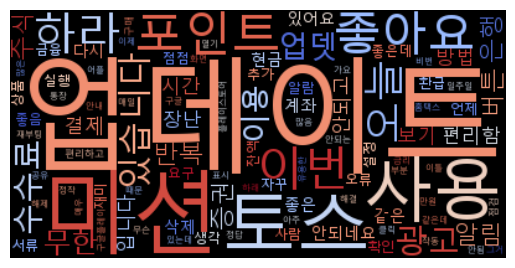

In [28]:
import matplotlib.pyplot as plt

font_path = 'C:/Windows/Fonts/malgun.ttf'

word_cloud = WordCloud(
    font_path=font_path,            # 한글 폰트 경로
    background_color='black',       # 워드클라우드 배경색
    max_font_size=400,              # 최대 폰트 크기 설정
    colormap='coolwarm'             # 워드클라우드의 색상 팔레트 설정
).generate_from_frequencies(dict(c_data))

plt.imshow(word_cloud, interpolation='bilinear')    # bilinear 보간법으로 부드럽게 표시
plt.axis('off')
plt.show()